In [1]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"
SKIP_TRAINING = False    # run_metrics.py sets this True: load weights from
                         # the checkpoint directly instead of calling
                         # trainer.fit(), which can silently retrain for the
                         # full schedule if the checkpoint does not cleanly
                         # resume to exactly MAX_EPOCHS.


In [2]:
# Parameters
MAX_EPOCHS = 2000
N_SAMPLES = 20
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "/Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/CM_metrics.csv"
SKIP_TRAINING = True


In [3]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


## 🛠️ Setup & Imports

In [4]:
!nvidia-smi

Fri Aug 21 15:46:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.158.01             Driver Version: 570.158.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:C8:00.0 Off |                    0 |
| N/A   32C    P0             66W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

In [6]:
import json
import math
import os
import zipfile
import glob
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')    # → consistency/  (for consistency_models)
sys.path.append('../../..')  # → 4dvarnet-starter-devs/  (for src)

from consistency_models.consistency_models_CM import (
    ConsistencySamplingAndEditingFewSteps_TimeEmbedding,
    ConsistencyTrainingFewSteps_TimeEmbedding,
    ema_decay_rate_schedule,
)
from consistency_models.utils import update_ema_model_

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("⚠️  properscoring not installed — CRPS disabled. Install with: pip install properscoring")

## 🧠 Implementation

### DataModule — SPDE Diffusion Dataset

In [7]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "../../../data/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset>
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * lat        (lat) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * time       (time) int64 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 ...
    y          (time, lat, lon) float32 ...
    OI         (time, lat, lon) float64 ...
    H11        (lat, lon) float32 ...
    H22        (lat, lon) float32 ...
    H12        (lat, lon) float32 ...
    Time       (time) int64 ...
    longitude  (lon) int64 ...
    latitude   (lat) int64 ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('lat', 'lon')  shape=(128, 128)  dtype=float32
  H22

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes — input (y): (5, 128, 128), tgt (x): (5, 128, 128)


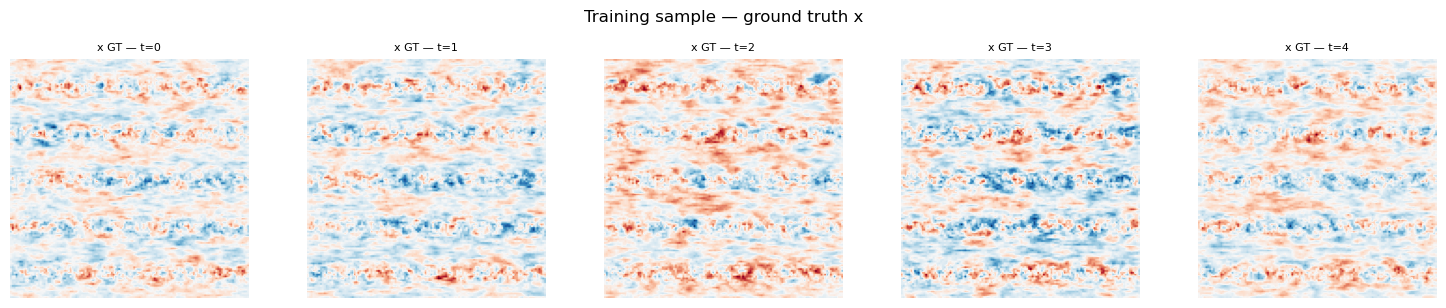

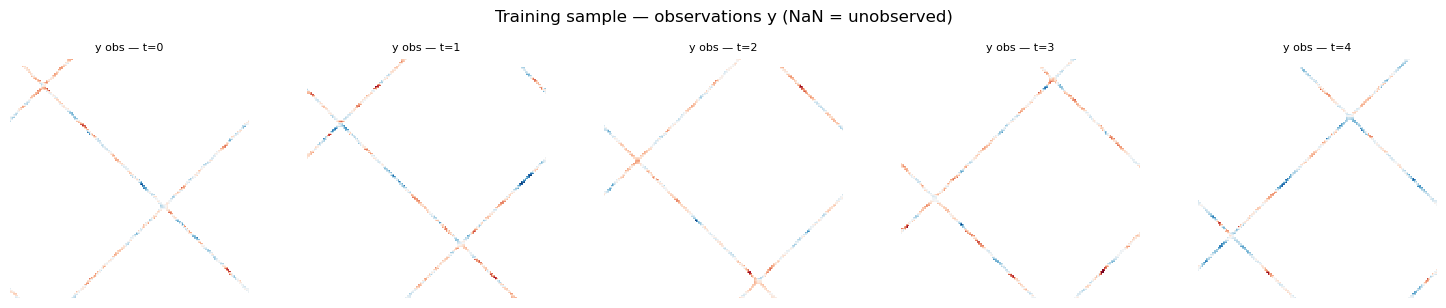

In [8]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = datamodule.window_size
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes — input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    im = ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x GT — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — ground truth x", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    im = ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y obs — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — observations y (NaN = unobserved)", y=1.01)
plt.tight_layout()
plt.show()

### UNet Building Blocks

Identical to the PWCM SSH notebook (GroupNorm, SelfAttention, UNetBlock, Downsample, Upsample, TimeLevelEmbedding).

In [9]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeLevelEmbedding(nn.Module):
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Padding utilities (100×100 → 104×104, must be a multiple of 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)  # left, right, top, bottom
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### UNet (Consistency Model)

The UNet takes as input the concatenation `(x_noisy, y_filled, mask_obs)` → `3×C` input channels.  
Conditioned by two temporal embeddings `σ` and `σ'` (concatenated → `2×time_level_channels`).  
Reflection padding to the nearest multiple of 8 is applied at input and removed at output.

In [10]:
@dataclass
class UNetConfig:
    channels: int = 5                                        # = window_size
    time_level_channels: int = 128
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 64)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class UNet(nn.Module):
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config

        # input = (x_noisy, y_filled, mask_obs) → 3 * channels
        self.input_projection = nn.Conv2d(
            config.channels * 3,
            config.top_blocks_channels[0],
            kernel_size=3, padding="same",
        )
        self.time_level_embedding = TimeLevelEmbedding(
            config.time_level_channels, config.time_level_scale
        )

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.output_projection = nn.Conv2d(
            config.top_blocks_channels[0], config.channels, kernel_size=3, padding="same"
        )

    def forward(self, x: Tensor, y: Tensor, time: Tensor, time_prime: Tensor) -> Tensor:
        mask_obs = (~torch.isnan(y)).to(x.dtype)
        y_filled = torch.nan_to_num(y, nan=0.0)

        # Pad H×W to nearest multiple of 8 (100×100 → 104×104)
        inp = torch.cat((x, y_filled, mask_obs), dim=1)   # (B, 3C, H, W)
        inp, padding = _pad_to_multiple(inp, multiple=8)

        h = self.input_projection(inp)

        # Two sigma embeddings concatenated along channel dim
        emb1 = self.time_level_embedding(time)
        emb2 = self.time_level_embedding(time_prime)
        time_level = torch.cat([emb1, emb2], dim=1)   # (B, 2*TLC, 1, 1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, padding)   # restaure H×W original

    # ---- builder helpers ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_level_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_level_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(UNetConfig(**config_dict))
        model.load_state_dict(
            torch.load(os.path.join(pretrained_path, "model.pt"), map_location="cpu")
        )
        return model


# Sanity check : 100×100 sera paddé à 104×104 en interne
C = datamodule.window_size
summary(
    UNet(UNetConfig(channels=C)),
    input_size=(
        (1, C, 100, 100),  # x_noisy
        (1, C, 100, 100),  # y_obs
        (1,),               # sigma
        (1,),               # sigma_prime
    ),
)

Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 5, 100, 100]          --
├─Conv2d: 1-1                                 [1, 64, 104, 104]         8,704
├─TimeLevelEmbedding: 1-2                     [1, 128, 1, 1]            64
│    └─Sequential: 2-1                        [1, 128, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
│    │    └─Rearrange: 3-4                    [1, 128, 1, 1]            --
├─TimeLevelEmbedding: 1-3                     [1, 128, 1, 1]            (recursive)
│    └─Sequential: 2-2                        [1, 128, 1, 1]            (recursive)
│    │    └─Linear: 3-5                       [1, 512]                  (recursive)
│    │    └─SiLU: 3-6                         [1, 512]   

### LightningModule — LitConsistencyModel

Identical to the PWCM SSH notebook. The `training_step` calls `ConsistencyTrainingFewSteps_TimeEmbedding` with `batch.tgt` (ground truth) and `batch.input` (observations with NaN).

In [11]:

@dataclass
class LitConsistencyModelConfig:
    initial_ema_decay_rate: float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    eval_nsteps: int = 10   # sampling steps for validation at end of each epoch


class LitConsistencyModel(LightningModule):
    def __init__(
        self,
        consistency_training: ConsistencyTrainingFewSteps_TimeEmbedding,
        student_model: UNet,
        teacher_model: UNet,
        ema_student_model: UNet,
        config: LitConsistencyModelConfig,
    ) -> None:
        super().__init__()
        self.consistency_training = consistency_training
        self.student_model = student_model
        self.teacher_model = teacher_model
        self.ema_student_model = ema_student_model
        self.config = config
        self.num_timesteps = self.consistency_training.initial_timesteps
        self._val_batch = None   # sera rempli dans on_fit_start

        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model = self.teacher_model.eval()
        self.ema_student_model = self.ema_student_model.eval()

    def on_fit_start(self) -> None:
        """Store a fixed validation batch for end-of-epoch evaluation."""
        try:
            dl = self.trainer.datamodule.val_dataloader()
            batch = next(iter(dl))
            if isinstance(batch, list):
                batch = batch[0]
            self._val_batch = batch
            print(f"✅ Val batch loaded: tgt={batch.tgt.shape}")
        except Exception as e:
            print(f"⚠️  Could not load a validation batch: {e}")

    def on_train_epoch_start(self) -> None:
        print(f"[Epoch {self.current_epoch}] num_timesteps={self.num_timesteps}")

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        output = self.consistency_training(
            self.student_model,
            self.teacher_model,
            batch.tgt,
            batch.input,
            self.global_step,
            10000,
        )
        self.num_timesteps = output.num_timesteps

        if batch_idx == 0:
            print(f"[Epoch {self.current_epoch}] sigmas={output.sigmas}")

        loss = F.mse_loss(
            output.predicted_next_from_intermediate,
            output.target_next_from_current,
        )
        self.log_dict({
            "train_loss":    loss,
            "num_timesteps": float(output.num_timesteps),
        })
        return loss

    def on_train_epoch_end(self) -> None:
        """Calcule le RMSE de reconstruction (10 steps, modèle EMA) sur le batch de validation."""
        if self._val_batch is None:
            print(f"[Epoch {self.current_epoch}]  ⚠️  No validation batch available.")
            return

        device = self.device
        dtype  = next(self.ema_student_model.parameters()).dtype

        x_gt = self._val_batch.tgt.to(device=device, dtype=dtype)
        y    = self._val_batch.input.to(device=device, dtype=dtype)
        B, C, H, W = x_gt.shape

        sampler = ConsistencySamplingAndEditingFewSteps_TimeEmbedding()
        self.ema_student_model.eval()

        with torch.no_grad():
            noise = torch.randn((B, C, H, W), device=device, dtype=dtype)
            x_hat, _ = sampler(
                self.ema_student_model,
                noise,
                y,
                nsteps=self.config.eval_nsteps,
                clip_denoised=False,
                verbose=False,
                stochastic=False,
            )

        rmse = (x_hat.float() - x_gt.float()).pow(2).mean().sqrt().item()
        print(
            f"[Epoch {self.current_epoch}]  "
            f"Val RMSE ({self.config.eval_nsteps} steps, EMA) = {rmse:.4f}"
        )
        self.log("val_rmse_ema", rmse)

    def on_train_batch_end(self, outputs, batch, batch_idx: int) -> None:
        ema_decay_rate = ema_decay_rate_schedule(
            self.num_timesteps,
            self.config.initial_ema_decay_rate,
            self.consistency_training.initial_timesteps,
        )
        update_ema_model_(self.teacher_model, self.student_model, ema_decay_rate)
        self.log_dict({"ema_decay_rate": ema_decay_rate})
        update_ema_model_(
            self.ema_student_model,
            self.student_model,
            self.config.student_model_ema_decay_rate,
        )

    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.student_model.parameters(),
            lr=self.config.lr, betas=self.config.betas,
        )
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]


## 🚀 Training

In [12]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, 'last.ckpt')
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f'Valid checkpoint: {last_ckpt}')
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, '*.ckpt'))
         if 'last' not in os.path.basename(p)],
        key=lambda p: float(p.split('train_loss=')[-1].replace('.ckpt', ''))
        if 'train_loss=' in p else float('inf'),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f'Valid checkpoint: {ckpt_path}')
            return ckpt_path
    print('No valid checkpoint found. Starting from scratch.')
    return None

C = datamodule.window_size

LOG_DIR        = 'logs_CT_CM_spde'
CKPT_DIR       = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH     = os.path.join(LOG_DIR, "best_model")

# RESET_TRAINING set by the parameters cell above

if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    resume_ckpt = None
    print("RESET_TRAINING=True -- starting from scratch")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

ct = ConsistencyTrainingFewSteps_TimeEmbedding(final_timesteps=17)

student_model     = UNet(UNetConfig(channels=C))
teacher_model     = UNet(UNetConfig(channels=C))
ema_student_model = UNet(UNetConfig(channels=C))
teacher_model.load_state_dict(student_model.state_dict())
ema_student_model.load_state_dict(student_model.state_dict())

lit_cm = LitConsistencyModel(
    ct, student_model, teacher_model, ema_student_model,
    LitConsistencyModelConfig(lr_scheduler_iters=1000),
)

trainer = Trainer(enable_progress_bar=False, 
    accelerator='gpu', max_epochs=MAX_EPOCHS, accumulate_grad_batches=4,
    precision='16-mixed', log_every_n_steps=1,
    logger=TensorBoardLogger('.', name=LOG_DIR, version=""),
    callbacks=[
        LearningRateMonitor(logging_interval='step'),
        ModelCheckpoint(
            dirpath=CKPT_DIR, monitor='train_loss',
            save_top_k=3, save_last=True,
            filename='{epoch:03d}-{step}-{train_loss:.4f}',
        ),
    ],
)

seed_everything(42)
trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
if SKIP_TRAINING:
    if resume_ckpt is None:
        raise RuntimeError(
            f"SKIP_TRAINING=True but no checkpoint found in {CKPT_DIR} -- "
            "run training first (submit_train.sbatch) before computing metrics."
        )
    print(f'[TRAINING] SKIP_TRAINING=True -- loading weights from {resume_ckpt} directly (trainer.fit() not called)', flush=True)
    _ckpt_state = torch.load(resume_ckpt, map_location='cpu')
    lit_cm.load_state_dict(_ckpt_state['state_dict'])
else:
    print(f'[TRAINING] resume_ckpt={resume_ckpt!r} | MAX_EPOCHS={MAX_EPOCHS}', flush=True)
    trainer.fit(lit_cm, datamodule, ckpt_path=resume_ckpt)

lit_cm.ema_student_model.save_pretrained(MODEL_PATH)
print(f'EMA model saved to: {MODEL_PATH}')


Valid checkpoint: logs_CT_CM_spde/checkpoints/last.ckpt


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /Odyssey/private/m19beauc/conda_envs/4dvarnet-starte ...
  rank_zero_warn(
Using 16bit Automatic Mixed Precision (AMP)


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


HPU available: False, using: 0 HPUs


[rank: 0] Global seed set to 42


[TRAINING] SKIP_TRAINING=True -- loading weights from logs_CT_CM_spde/checkpoints/last.ckpt directly (trainer.fit() not called)


EMA model saved to: logs_CT_CM_spde/best_model


## 🎲 Sampling & Evaluation

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

unet = UNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"✅ Model loaded from: {MODEL_PATH}")

✅ Model loaded from: logs_CT_CM_spde/best_model


### Test batch

In [14]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

[rank: 0] Global seed set to 42


### Ensemble generation (N_SAMPLES members)

In [15]:
# N_SAMPLES set by the parameters cell above
consistency_sampling = ConsistencySamplingAndEditingFewSteps_TimeEmbedding()

C  = datamodule.window_size
H, W = batch.tgt.shape[-2], batch.tgt.shape[-1]  # 100×100

samples = []
samples_process = []

with torch.no_grad():
    for i in range(N_SAMPLES):
        sample, sample_process = consistency_sampling(
            unet,
            torch.randn((1, C, H, W), device=device, dtype=dtype),
            batch.input.to(device=device, dtype=dtype),
            nsteps=15,
            clip_denoised=False,
            verbose=(i == 0),
            stochastic=True,
        )
        samples.append(sample)
        samples_process.append(sample_process)
        print(f"  Sample {i+1}/{N_SAMPLES} done", end="\r")
print(f"\n✅ {N_SAMPLES} ensemble members generated")

# Ensemble mean and standard deviation
ensemble = torch.stack(samples, dim=0).squeeze(1)   # (N, C, H, W)
ens_mean = ensemble.mean(dim=0)                      # (C, H, W)
ens_std  = ensemble.std(dim=0)                       # (C, H, W)

  Sample 20/20 done
✅ 20 ensemble members generated


### Figures

  Saved: figures/CM_spde/CM_spde_obs.png


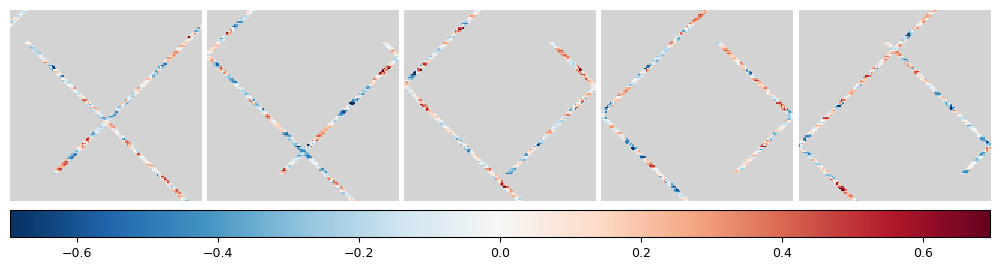

  Saved: figures/CM_spde/CM_spde_gt.png


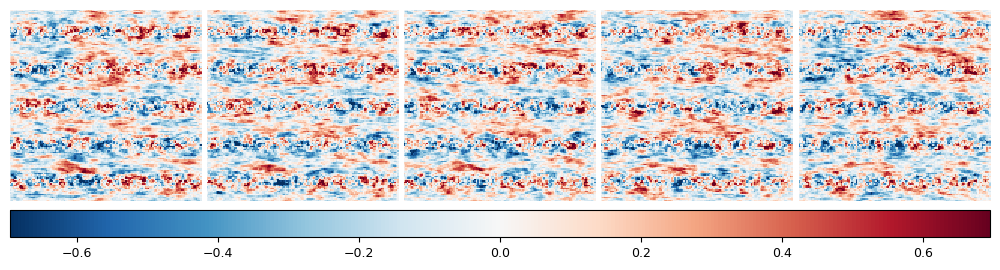

  Saved: figures/CM_spde/CM_spde_oi.png


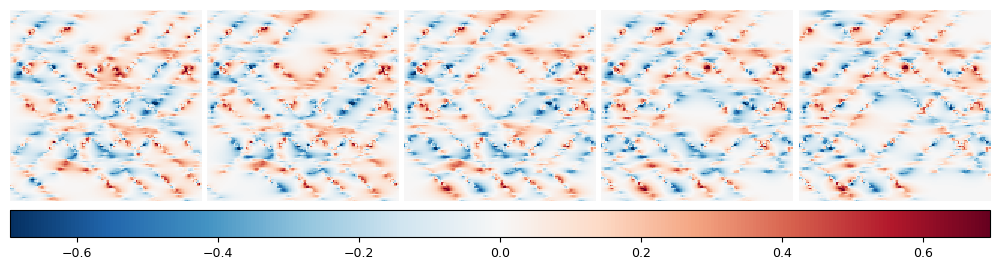

  Saved: figures/CM_spde/CM_spde_cm_mean.png


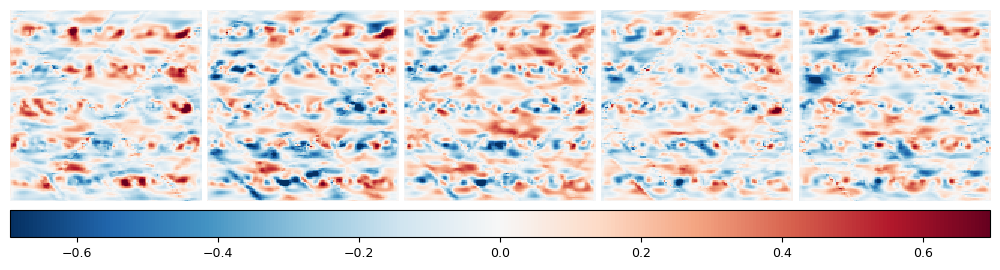

  Saved: figures/CM_spde/CM_spde_cm_spread.png


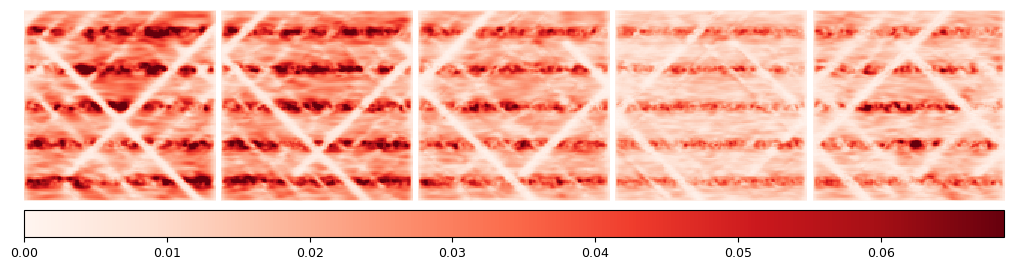

  Saved: figures/CM_spde/CM_spde_member0.png


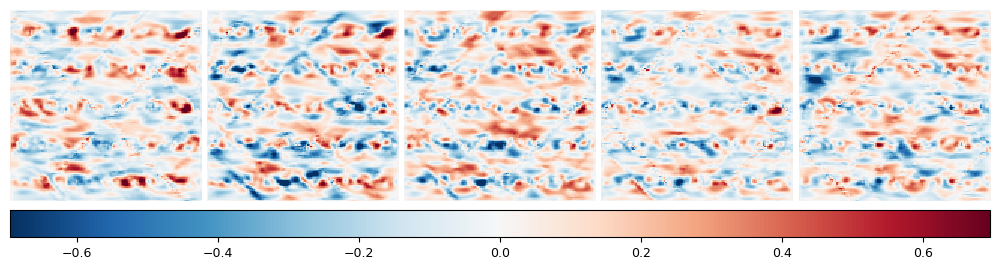

  Saved: figures/CM_spde/CM_spde_member1.png


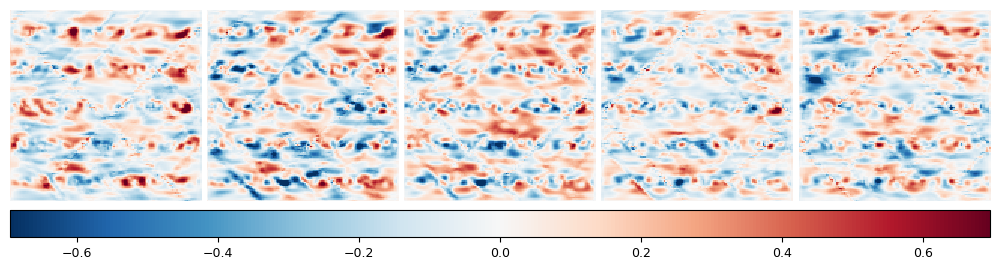

In [16]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'CM_spde'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

C       = datamodule.window_size

# Physical fields over full assimilation window
m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]

obs_phys  = batch.input[0].float().numpy() * s_norm + m_norm   # (C,H,W) NaN ok
gt_phys   = batch.tgt[0].float().numpy()   * s_norm + m_norm   # (C,H,W)
oi_phys   = datamodule.oi[start_t: start_t + C].astype(np.float32)  # (C,H,W)
mean_phys = ens_mean.float().cpu().numpy() * s_norm + m_norm    # (C,H,W)
std_phys  = ens_std.float().cpu().numpy()  * s_norm             # (C,H,W)
mbr0_phys = ensemble[0].float().cpu().numpy() * s_norm + m_norm # (C,H,W)
mbr1_phys = ensemble[1].float().cpu().numpy() * s_norm + m_norm # (C,H,W)

# Shared colorbar range for all field images
vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f
vmax_s = float(np.nanpercentile(std_phys, 99))

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')
cmap_s = plt.cm.Reds.copy();   cmap_s.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    # One image per variable: 1 row x C cols, horizontal colorbar, no title
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C,
                  left=0.01, right=0.99,
                  top=0.99,
                  bottom=0.01,
                  height_ratios=[FH, CB_H],
                  hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

# One figure per variable (1 row x C cols, shared vmin/vmax per type)
figures = [
    (obs_phys,  f'{FIG_TAG}_obs',     vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',      vmin_f, vmax_f, cmap_f),
    (oi_phys,   f'{FIG_TAG}_oi',      vmin_f, vmax_f, cmap_f),
    (mean_phys, f'{FIG_TAG}_cm_mean', vmin_f, vmax_f, cmap_f),
    (std_phys,  f'{FIG_TAG}_cm_spread', 0.0,  vmax_s, cmap_s),
    (mbr0_phys, f'{FIG_TAG}_member0', vmin_f, vmax_f, cmap_f),
    (mbr1_phys, f'{FIG_TAG}_member1', vmin_f, vmax_f, cmap_f),
]

for data, fname, vmin, vmax, cmap in figures:
    _save_strip(data, fname, vmin, vmax, cmap)

### Transport process -- trajectoire de debruitage (membre 0)

  Saved: figures/CM_spde/CM_spde_transport.png


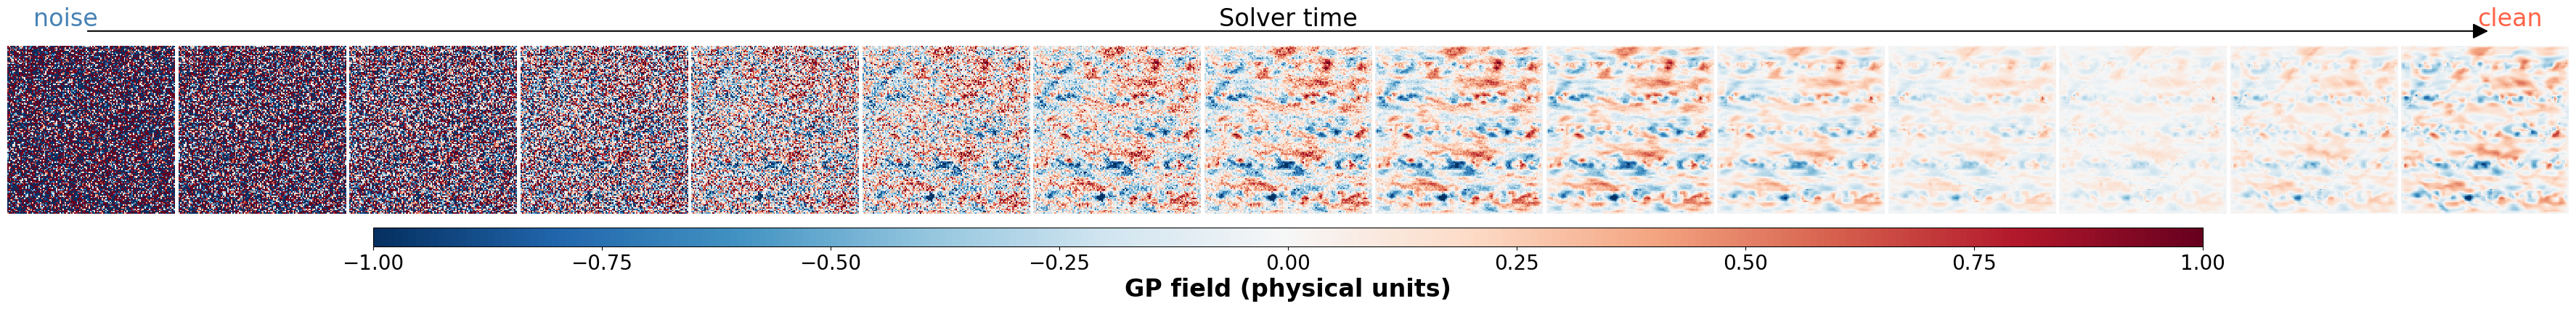

In [17]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

T_CH   = datamodule.window_size // 2   # displayed time channel (t=2)
N_SHOW = 10                             # max frames

proc = samples_process[0]
if proc.ndim == 5:   # (nsteps, B, C, H, W)
    transport_n = proc[:, 0, T_CH, :, :].float().cpu().numpy()
else:                # (nsteps, 1, C, H, W)
    transport_n = proc[:, 0, 0, T_CH, :, :].float().cpu().numpy()
transport_p = transport_n * s_norm + m_norm

nfr = transport_p.shape[0]
stride = max(1, nfr // N_SHOW)
idx_show = list(range(0, nfr, stride))
if (nfr - 1) not in idx_show:
    idx_show.append(nfr - 1)
frames = transport_p[idx_show]
nf = len(frames)

# Layout (all in inches, from bottom to top)
FW, FH   = 2.4, 2.4   # frame width / height
ARR_H    = 0.28        # arrow zone
GAP_1    = 0.14        # gap: arrow -> colorbar
CB_H     = 0.26        # colorbar height
GAP_2    = 0.16        # gap: colorbar -> images

fig_w = nf * FW
fig_h = ARR_H + GAP_1 + CB_H + GAP_2 + FH

# Figure-fraction positions (y = 0 at bottom)
arr_y_in   = ARR_H / 2                                # arrow center (inches)
cb_bot_in  = ARR_H + GAP_1                            # colorbar bottom (inches)
img_bot_in = ARR_H + GAP_1 + CB_H + GAP_2            # image strip bottom (inches)

arr_y_f   = arr_y_in   / fig_h
cb_bot_f  = cb_bot_in  / fig_h
cb_h_f    = CB_H       / fig_h
img_bot_f = img_bot_in / fig_h

fig = plt.figure(figsize=(fig_w, fig_h))

# Image strip (GridSpec leaves margins via bottom/top)
gs = GridSpec(1, nf, left=0.01, right=0.99,
              top=0.99, bottom=img_bot_f,
              hspace=0, wspace=0.02)

vmax_t = float(np.nanpercentile(np.abs(transport_p), 99))
vmax_t = 1
cmap_t = plt.cm.RdBu_r
for i in range(nf):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(frames[i], origin='lower', cmap=cmap_t,
              vmin=-vmax_t, vmax=vmax_t, interpolation='nearest')
    ax.axis('off')

# Horizontal colorbar
cb_ax = fig.add_axes([0.15, cb_bot_f, 0.70, cb_h_f])
sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(-vmax_t, vmax_t))
sm.set_array([])
cb = fig.colorbar(sm, cax=cb_ax, orientation='horizontal')
cb.set_label('GP field (physical units)', fontsize=24, fontweight='bold')
cb.ax.tick_params(labelsize=20)

# Temporal arrow
fig.add_artist(mpatches.FancyArrowPatch(
    (0.04, 1+arr_y_f), (0.96, 1+arr_y_f),
    transform=fig.transFigure, arrowstyle='-|>',
    color='black', mutation_scale=32, linewidth=1.5,
))
fig.text(0.02, 1+arr_y_f, 'noise', va='bottom', ha='left',  fontsize=24, color='steelblue')
fig.text(0.98, 1+arr_y_f, 'clean', va='bottom', ha='right', fontsize=24, color='tomato')
fig.text(0.50, 1+arr_y_f, 'Solver time', va='bottom', ha='center', fontsize=24)

fpath = os.path.join(FIG_DIR, f'{FIG_TAG}_transport.png')
fig.savefig(fpath, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath}')
plt.show()

## 📊 Metrics — Consistency Model vs OI

Evaluation at the **centre of the assimilation window** (`t=2`, `C=5`).

| Metric | Description |
|---|---|
| **Score ↑** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE ↓** | Root Mean Square Error vs GT |
| **σ_pred** | Standard deviation of the ensemble mean |
| **CRPS ↓** | Continuous Ranked Probability Score at **observed** pixels |
| **λx ↓** | Resolved scale (px): wavelength where spectral score = 0.5 |

[rank: 0] Global seed set to 42


Evaluated 225 (test sample, timestep) pairs across the full test set

## Metrics -- full test set (whole domain), n=225 (sample,t) pairs



,RMSE,lambda_x,CRPS
Method,,,
"CM (ens. mean, full test set)",0.2298 $\pm$ 0.0171,50.6 $\pm$ 42.8,0.1094 $\pm$ 0.0336
OI baseline (full test set),0.2253 $\pm$ 0.0040,43.1 $\pm$ 35.9,--


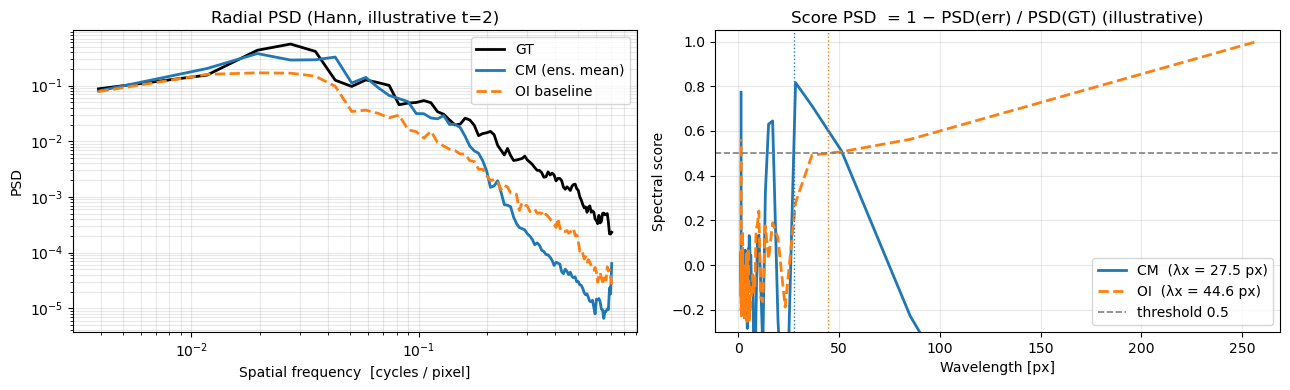

In [18]:
import sys
sys.path.append('../..')   # -> consistency/
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale

DX_PX  = 1.0                           # 1 pixel = 1 km (assumption)

m_norm, s_norm = datamodule.norm_stats()

# ── Full test-set evaluation ─────────────────────────────────────────────
# Loops over EVERY batch of datamodule.test_dataloader() (not just the first
# one used for the illustrative figures above) and EVERY timestep of the
# assimilation window (not just T_EVAL=window_size//2), regenerating a fresh
# ensemble each time, and comparing against the matching OI baseline slice
# for every (sample, timestep) pair. This is the expensive part (N_SAMPLES x
# n_test_samples consistency-sampling calls) -- N_SAMPLES was reduced from 50
# to 20 in methods.yaml specifically to keep a full-test-set pass affordable.
# GP is a synthetic continuous field, so unlike SIC there is no MIZ-style
# domain restriction -- metrics are aggregated over the whole spatial domain.
_all_cm = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'crps': [], 'lambda_x': []}
_all_oi = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'lambda_x': []}
_n_pairs = 0
_sample_counter = 0

seed_everything(42)
for _tb in datamodule.test_dataloader():
    _gt_b = _tb.tgt.to(device=device, dtype=dtype)      # (B, C, H, W)
    _y_b  = _tb.input.to(device=device, dtype=dtype)     # (B, C, H, W)
    _Bb, _Cb, _Hb, _Wb = _gt_b.shape
    _valid_b   = ~torch.isnan(_gt_b)
    _obsmask_b = ~torch.isnan(_y_b)

    for _bi in range(_Bb):
        _start_t = datamodule.test_ds.indices[_sample_counter]
        _sample_counter += 1

        with torch.no_grad():
            _members = [
                consistency_sampling(
                    unet,
                    torch.randn((1, _Cb, _Hb, _Wb), device=device, dtype=dtype),
                    _y_b[_bi:_bi + 1],
                    nsteps=15, clip_denoised=False, verbose=False, stochastic=True,
                )[0]
                for _ in range(N_SAMPLES)
            ]
        _ens_b = torch.stack(_members, dim=0).squeeze(1)   # (N, C, H, W) normalised
        _ens_mean_b = _ens_b.mean(0)

        for _t in range(_Cb):
            _valid_t = _valid_b[_bi, _t].cpu().numpy()
            if _valid_t.sum() < 10:
                continue
            _gt_p   = _gt_b[_bi, _t].float().cpu().numpy() * s_norm + m_norm
            _mean_p = _ens_mean_b[_t].float().cpu().numpy() * s_norm + m_norm
            _ens_p  = _ens_b[:, _t].float().cpu().numpy()   * s_norm + m_norm
            _oi_p   = datamodule.oi[_start_t + _t].astype(np.float32)

            _gt_v, _pred_v = _gt_p[_valid_t], _mean_p[_valid_t]
            _sigma = float(np.std(_gt_v))
            if _sigma <= 0:
                continue
            _rmse  = float(np.sqrt(np.mean((_pred_v - _gt_v) ** 2)))
            _score = 1.0 - _rmse / _sigma
            _sigma_pred = float(np.std(_pred_v))

            _gt_f   = np.nan_to_num(_gt_p,   nan=0.0)
            _pred_f = np.nan_to_num(_mean_p, nan=0.0)
            _wl, _, _, _spec = psd_spectral_score(_pred_f, _gt_f, dx=DX_PX)
            _lam = resolved_scale(_wl, _spec, threshold=0.5)

            _crps_val = np.nan
            if HAS_PROPERSCORING:
                _obs_t  = _obsmask_b[_bi, _t].cpu().numpy()
                _obs_ij = np.argwhere(_valid_t & _obs_t)
                if len(_obs_ij) > 0:
                    _stride = max(1, len(_obs_ij) // 50)   # subsample -- CRPS is O(n) Python loop
                    _crps_val = float(np.mean([
                        crps_ensemble(float(_gt_p[i, j]), _ens_p[:, i, j])
                        for i, j in _obs_ij[::_stride]
                    ]))

            _all_cm['score'].append(_score)
            _all_cm['rmse'].append(_rmse)
            _all_cm['sigma_gt'].append(_sigma)
            _all_cm['sigma_pred'].append(_sigma_pred)
            _all_cm['crps'].append(_crps_val)
            _all_cm['lambda_x'].append(_lam)

            # OI baseline, same (sample, timestep) pair
            _oi_v = _oi_p[_valid_t]
            _rmse_oi  = float(np.sqrt(np.mean((_oi_v - _gt_v) ** 2)))
            _score_oi = 1.0 - _rmse_oi / _sigma
            _sigma_oi_pred = float(np.std(_oi_v))
            _oi_f = np.nan_to_num(_oi_p, nan=0.0)
            _wl_oi, _, _, _spec_oi = psd_spectral_score(_oi_f, _gt_f, dx=DX_PX)
            _lam_oi = resolved_scale(_wl_oi, _spec_oi, threshold=0.5)
            _all_oi['score'].append(_score_oi)
            _all_oi['rmse'].append(_rmse_oi)
            _all_oi['sigma_gt'].append(_sigma)
            _all_oi['sigma_pred'].append(_sigma_oi_pred)
            _all_oi['lambda_x'].append(_lam_oi)

            _n_pairs += 1

print(f"Evaluated {_n_pairs} (test sample, timestep) pairs across the full test set")

def _agg(vals):
    a = np.asarray(vals, dtype=float)
    a = a[~np.isnan(a)]
    return (float(np.mean(a)), float(np.std(a))) if len(a) else (np.nan, np.nan)

def _row(all_dict, label, has_crps=True):
    score_m, score_s = _agg(all_dict['score'])
    rmse_m, rmse_s   = _agg(all_dict['rmse'])
    sgt_m, sgt_s     = _agg(all_dict['sigma_gt'])
    spr_m, spr_s     = _agg(all_dict['sigma_pred'])
    lam_m, lam_s     = _agg(all_dict['lambda_x'])
    row = {
        'Method'     : label,
        'Score up'   : f'{score_m:.3f} ± {score_s:.3f}',
        'RMSE down'  : f'{rmse_m:.4f} ± {rmse_s:.4f}',
        'sigma_GT'   : f'{sgt_m:.4f} ± {sgt_s:.4f}',
        'sigma_pred' : f'{spr_m:.4f} ± {spr_s:.4f}',
        'lambda_x px': f'{lam_m:.1f} ± {lam_s:.1f}' if not np.isnan(lam_m) else '?',
    }
    if has_crps:
        crps_m, crps_s = _agg(all_dict['crps'])
        row['CRPS down'] = f'{crps_m:.4f} ± {crps_s:.4f}' if not np.isnan(crps_m) else '--'
    return row

row_cm = _row(_all_cm, 'CM (ens. mean, full test set)', has_crps=True)
row_oi = _row(_all_oi, 'OI baseline (full test set)',    has_crps=False)
row_oi['CRPS down'] = '--'

df_metrics = pd.DataFrame([row_cm, row_oi]).set_index('Method')
df_metrics = df_metrics[['Score up','RMSE down','sigma_GT','sigma_pred','CRPS down','lambda_x px']]
df_metrics.columns = ['Score ↑','RMSE ↓','σ_GT','σ_pred','CRPS ↓','λx [px]']
print(f'\n## Metrics -- full test set (whole domain), n={_n_pairs} (sample,t) pairs\n')

# ── Canonicalize columns for the cross-method LaTeX table (make_latex_table.py) ──
# Every notebook in the suite must expose the SAME column names (RMSE,
# lambda_x, CRPS) regardless of internal naming (unicode arrows/sigma vs
# plain ascii, [px]/[deg] unit suffixes) -- otherwise make_latex_table.py's
# column-union logic creates duplicate columns (e.g. both "RMSE" and
# "RMSE ↓") instead of one shared column per metric. Score/sigma_GT/sigma_pred
# are dropped (not part of the target table). "±" is replaced with the
# LaTeX-safe "$\pm$" so the aggregated .tex table compiles cleanly.
_col_map = {
    'RMSE': 'RMSE', 'RMSE ↓': 'RMSE', 'RMSE down': 'RMSE',
    'lambda_x': 'lambda_x', 'lambda_x [px]': 'lambda_x', 'lambda_x [deg]': 'lambda_x',
    'lambda_x px': 'lambda_x', 'lambda_x [km]': 'lambda_x',
    'λx [px]': 'lambda_x', 'λx [deg]': 'lambda_x', 'λx px': 'lambda_x', 'λx [km]': 'lambda_x',
    'CRPS': 'CRPS', 'CRPS ↓': 'CRPS', 'CRPS down': 'CRPS',
}
df_metrics = df_metrics.rename(columns=_col_map)
for _c in df_metrics.columns:
    df_metrics[_c] = df_metrics[_c].apply(lambda v: v.replace('±', '$\\pm$') if isinstance(v, str) else v)
_keep = [c for c in ['RMSE', 'lambda_x', 'CRPS'] if c in df_metrics.columns]
df_metrics = df_metrics[_keep]

display(df_metrics)

# ── Illustrative PSD plot (single example, T_EVAL=window_size//2 of the first
# test batch, same one used by the figures above) -- qualitative check only,
# NOT the quantitative table (that's df_metrics above, full test set now).
T_EVAL = datamodule.window_size // 2
start_t = datamodule.test_ds.indices[0]
gt_p_ex   = batch.tgt[0, T_EVAL].float().numpy() * s_norm + m_norm
mean_p_ex = ens_mean[T_EVAL].float().cpu().numpy() * s_norm + m_norm
oi_p_ex   = datamodule.oi[start_t + T_EVAL].astype(np.float32)

wl_gt,  psd_gt_sig  = radial_psd_2d(gt_p_ex,   dx=DX_PX)
wl_cm2, psd_cm_sig  = radial_psd_2d(mean_p_ex, dx=DX_PX)
wl_oi2, psd_oi_sig  = radial_psd_2d(oi_p_ex,   dx=DX_PX)
wl_cm, _, _, spec_cm = psd_spectral_score(mean_p_ex, gt_p_ex, dx=DX_PX)
wl_oi, _, _, spec_oi = psd_spectral_score(oi_p_ex,   gt_p_ex, dx=DX_PX)
lambda_x_cm = resolved_scale(wl_cm, spec_cm)
lambda_x_oi = resolved_scale(wl_oi, spec_oi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for wl, psd, color, ls, lbl in [
    (wl_gt,  psd_gt_sig,  'black',   '-',  'GT'),
    (wl_cm2, psd_cm_sig,  'C0',      '-',  'CM (ens. mean)'),
    (wl_oi2, psd_oi_sig,  'C1',      '--', 'OI baseline'),
]:
    v = np.isfinite(wl) & np.isfinite(psd) & (wl > 0) & (psd > 0)
    ax.loglog(1.0/wl[v], psd[v], color=color, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Spatial frequency  [cycles / pixel]')
ax.set_ylabel('PSD')
ax.set_title(f'Radial PSD (Hann, illustrative t={T_EVAL})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
lbl_cm = f'CM  (λx = {lambda_x_cm:.1f} px)' if not np.isnan(lambda_x_cm) else 'CM'
lbl_oi = f'OI  (λx = {lambda_x_oi:.1f} px)' if not np.isnan(lambda_x_oi) else 'OI'
for wl, spec, color, ls, lbl in [
    (wl_cm, spec_cm, 'C0', '-',  lbl_cm),
    (wl_oi, spec_oi, 'C1', '--', lbl_oi),
]:
    v = np.isfinite(wl) & np.isfinite(spec)
    ax.plot(wl[v], spec[v], color=color, ls=ls, lw=2, label=lbl)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_cm):
    ax.axvline(lambda_x_cm, color='C0', lw=1, ls=':')
if not np.isnan(lambda_x_oi):
    ax.axvline(lambda_x_oi, color='C1', lw=1, ls=':')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD  = 1 − PSD(err) / PSD(GT) (illustrative)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')


Metrics written to /Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/CM_metrics.csv
